In [1]:
import os
import yaml
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from pathlib import Path

# Project root
PROJECT_ROOT = Path.cwd().parent

# Dataset folder
DATA_DIR = PROJECT_ROOT / "data"

print("Project root:", PROJECT_ROOT)
print("Data folder:", DATA_DIR)
print("Data folder exists:", DATA_DIR.exists())

Project root: /Users/priyansh/Downloads/airport-baggage-screening
Data folder: /Users/priyansh/Downloads/airport-baggage-screening/data
Data folder exists: True


In [3]:
YAML_PATH = DATA_DIR / "data.yaml"

print("YAML path:", YAML_PATH)
print("YAML exists:", YAML_PATH.exists())

YAML path: /Users/priyansh/Downloads/airport-baggage-screening/data/data.yaml
YAML exists: False


In [4]:
with open(YAML_PATH, "r") as file:
    data_config = yaml.safe_load(file)

print("Dataset configuration:")
print(data_config)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/priyansh/Downloads/airport-baggage-screening/data/data.yaml'

In [ ]:

DATA_DIR

PosixPath('/Users/priyansh/Downloads/airport-baggage-screening/data')

In [ ]:
class_names = data_config["names"]

print("Number of classes:", len(class_names))
print()

for class_id, class_name in enumerate(class_names):
    print(f"{class_id:2d} → {class_name}")

Number of classes: 12

 0 → Baton
 1 → Pliers
 2 → Hammer
 3 → Powerbank
 4 → Scissors
 5 → Wrench
 6 → Gun
 7 → Bullet
 8 → Sprayer
 9 → HandCuffs
10 → Knife
11 → Lighter


In [ ]:
IMAGE_DIR = DATA_DIR / "images"
LABEL_DIR = DATA_DIR / "labels"

TRAIN_IMAGES = IMAGE_DIR / "train"
VAL_IMAGES = IMAGE_DIR / "val"
TEST_IMAGES = IMAGE_DIR / "test"

TRAIN_LABELS = LABEL_DIR / "train"
VAL_LABELS = LABEL_DIR / "val"
TEST_LABELS = LABEL_DIR / "test"

print("Train images:", TRAIN_IMAGES.exists())
print("Validation images:", VAL_IMAGES.exists())
print("Test images:", TEST_IMAGES.exists())

print("Train labels:", TRAIN_LABELS.exists())
print("Validation labels:", VAL_LABELS.exists())
print("Test labels:", TEST_LABELS.exists())

Train images: True
Validation images: True
Test images: True
Train labels: True
Validation labels: True
Test labels: True


In [ ]:
def count_files(folder, extension):
    return len(list(folder.glob(f"*.{extension}")))


split_counts = {
    "Train": count_files(TRAIN_IMAGES, "jpg"),
    "Validation": count_files(VAL_IMAGES, "jpg"),
    "Test": count_files(TEST_IMAGES, "jpg")
}

label_counts = {
    "Train": count_files(TRAIN_LABELS, "txt"),
    "Validation": count_files(VAL_LABELS, "txt"),
    "Test": count_files(TEST_LABELS, "txt")
}

print("IMAGE COUNTS")
print("=" * 35)

for split, count in split_counts.items():
    print(f"{split:<12}: {count:,}")

print("\nLABEL COUNTS")
print("=" * 35)

for split, count in label_counts.items():
    print(f"{split:<12}: {count:,}")

IMAGE COUNTS
Train       : 10,982
Validation  : 1,373
Test        : 1,373

LABEL COUNTS
Train       : 10,982
Validation  : 1,373
Test        : 1,358


In [ ]:
total_images = sum(split_counts.values())

print(f"Total images: {total_images:,}\n")

for split, count in split_counts.items():
    percentage = (count / total_images) * 100
    print(f"{split:<12}: {count:,} images ({percentage:.2f}%)")

Total images: 13,728

Train       : 10,982 images (80.00%)
Validation  : 1,373 images (10.00%)
Test        : 1,373 images (10.00%)


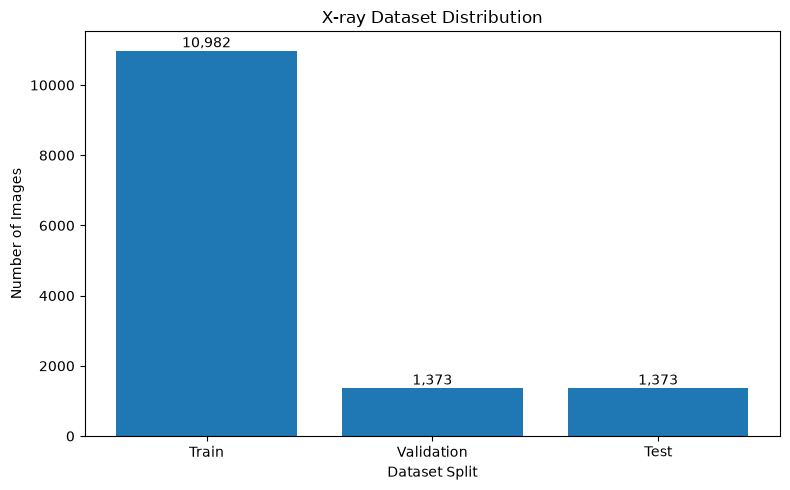

In [ ]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    split_counts.keys(),
    split_counts.values()
)

plt.title("X-ray Dataset Distribution")
plt.xlabel("Dataset Split")
plt.ylabel("Number of Images")

for bar, count in zip(bars, split_counts.values()):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [ ]:
class_counts = {i: 0 for i in range(len(class_names))}

all_label_files = list(LABEL_DIR.glob("*/*.txt"))

for label_file in all_label_files:

    with open(label_file, "r") as file:

        for line in file:

            line = line.strip()

            if not line:
                continue

            values = line.split()

            class_id = int(values[0])

            if class_id in class_counts:
                class_counts[class_id] += 1

print("OBJECT DISTRIBUTION")
print("=" * 45)

for class_id, count in class_counts.items():
    print(
        f"{class_id:2d} | "
        f"{class_names[class_id]:12s} | "
        f"{count:,}"
    )

OBJECT DISTRIBUTION
 0 | Baton        | 1,488
 1 | Pliers       | 1,499
 2 | Hammer       | 1,508
 3 | Powerbank    | 1,510
 4 | Scissors     | 1,511
 5 | Wrench       | 1,495
 6 | Gun          | 1,519
 7 | Bullet       | 1,499
 8 | Sprayer      | 1,495
 9 | HandCuffs    | 1,501
10 | Knife        | 1,495
11 | Lighter      | 1,494


In [ ]:
total_annotations = sum(class_counts.values())

print(f"Total annotated objects: {total_annotations:,}")

Total annotated objects: 18,014


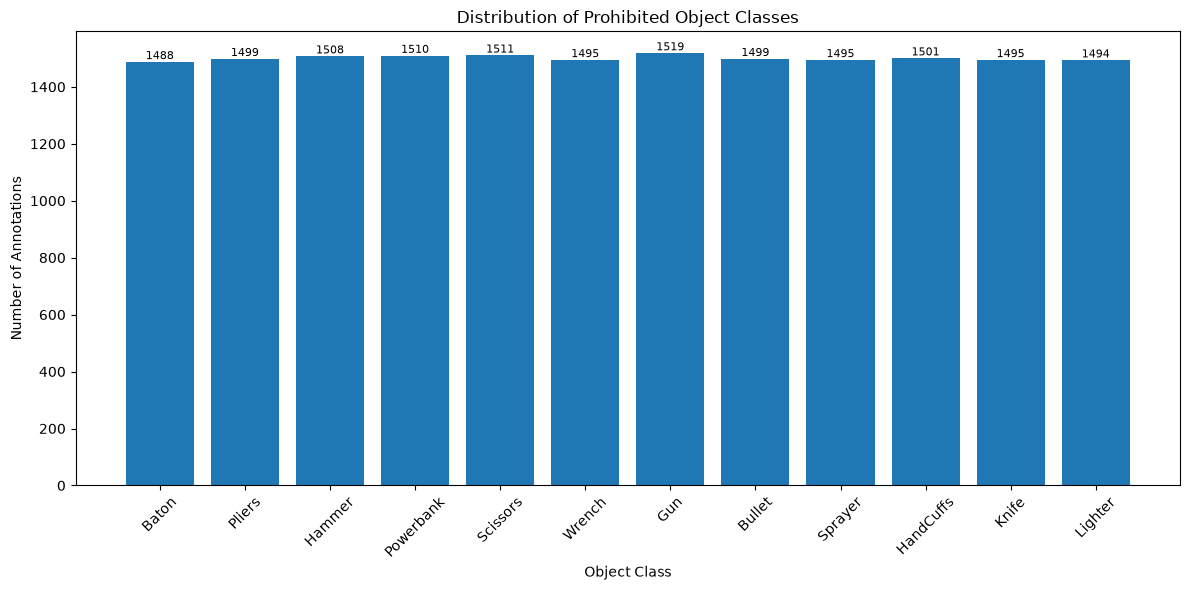

In [ ]:
names = [class_names[i] for i in class_counts]
counts = [class_counts[i] for i in class_counts]

plt.figure(figsize=(12, 6))

bars = plt.bar(names, counts)

plt.title("Distribution of Prohibited Object Classes")
plt.xlabel("Object Class")
plt.ylabel("Number of Annotations")

plt.xticks(rotation=45)

for bar, count in zip(bars, counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(count),
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()

In [ ]:
minimum_class = min(class_counts.values())
maximum_class = max(class_counts.values())

difference = maximum_class - minimum_class
balance_difference_percent = (difference / minimum_class) * 100

print("Class balance analysis")
print("=" * 40)

print(f"Minimum class count : {minimum_class:,}")
print(f"Maximum class count : {maximum_class:,}")
print(f"Difference          : {difference}")
print(f"Difference (%)      : {balance_difference_percent:.2f}%")

Class balance analysis
Minimum class count : 1,488
Maximum class count : 1,519
Difference          : 31
Difference (%)      : 2.08%


In [ ]:
train_images = sorted(TRAIN_IMAGES.glob("*.jpg"))

print(f"Training images found: {len(train_images):,}")

sample_image_path = train_images[0]

print("Sample image:")
print(sample_image_path)

Training images found: 10,982
Sample image:
/Users/priyansh/Downloads/airport-baggage-screening/data/images/train/PID_xray_00000.jpg


Image: PID_xray_00000.jpg
Image dimensions: (448, 620, 3)


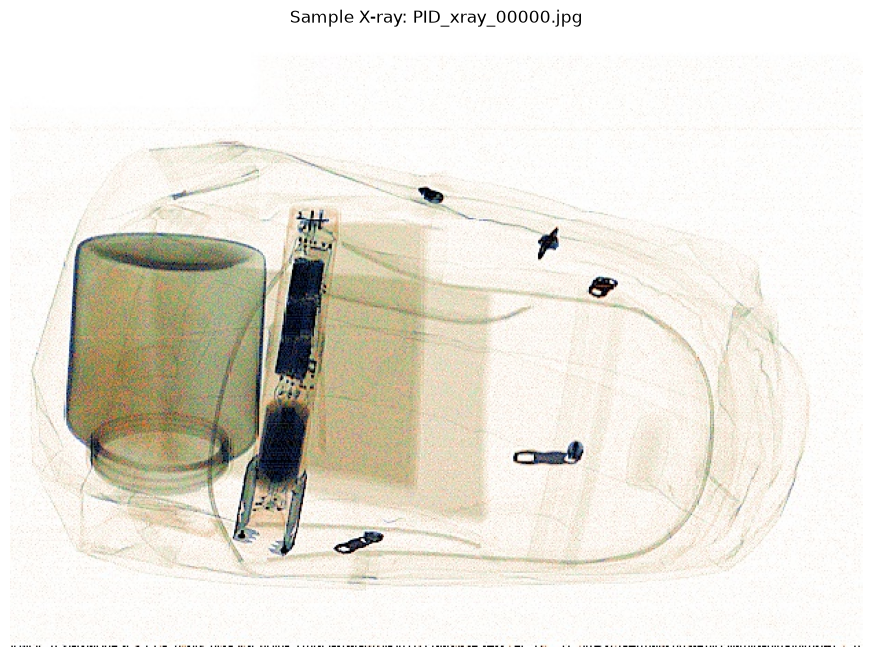

In [ ]:
image = cv2.imread(str(sample_image_path))

if image is None:
    raise ValueError("Could not read the image.")

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print("Image:", sample_image_path.name)
print("Image dimensions:", image_rgb.shape)

plt.figure(figsize=(12, 8))
plt.imshow(image_rgb)
plt.title(f"Sample X-ray: {sample_image_path.name}")
plt.axis("off")
plt.show()

In [ ]:
sample_label_path = TRAIN_LABELS / f"{sample_image_path.stem}.txt"

print("Image:")
print(sample_image_path)

print("\nLabel:")
print(sample_label_path)

print("\nLabel exists:", sample_label_path.exists())

Image:
/Users/priyansh/Downloads/airport-baggage-screening/data/images/train/PID_xray_00000.jpg

Label:
/Users/priyansh/Downloads/airport-baggage-screening/data/labels/train/PID_xray_00000.txt

Label exists: True


In [ ]:
with open(sample_label_path, "r") as file:
    annotations = file.readlines()

print("YOLO annotations:\n")

for annotation in annotations:
    print(annotation.strip())

YOLO annotations:

0 0.323928 0.568799 0.130358 0.570267


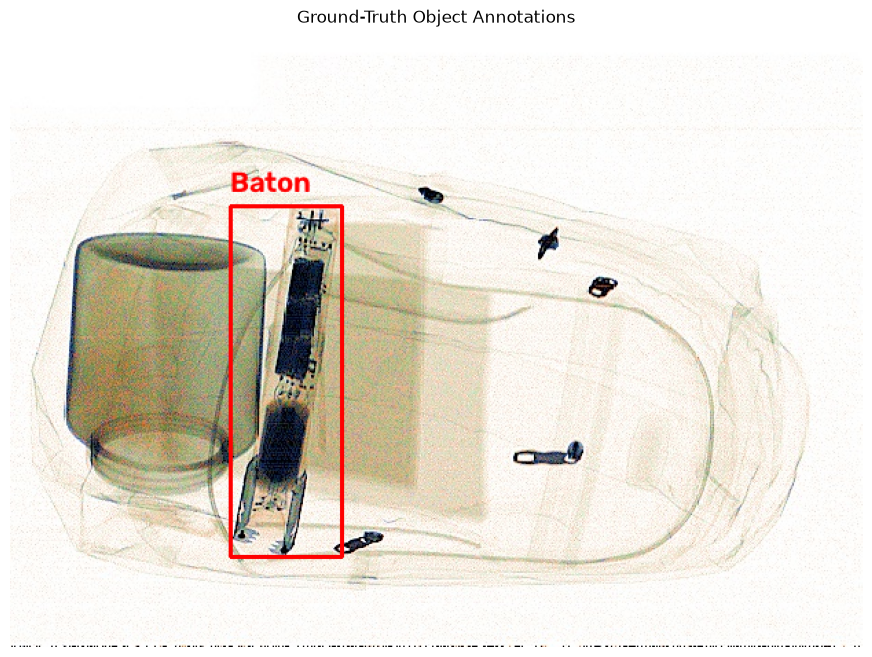

In [ ]:
image_with_boxes = image_rgb.copy()

height, width = image_with_boxes.shape[:2]

for annotation in annotations:

    values = annotation.strip().split()

    if len(values) != 5:
        continue

    class_id = int(values[0])
    x_center = float(values[1])
    y_center = float(values[2])
    box_width = float(values[3])
    box_height = float(values[4])

    # Convert normalized coordinates to pixels
    x_center *= width
    y_center *= height
    box_width *= width
    box_height *= height

    x1 = int(x_center - box_width / 2)
    y1 = int(y_center - box_height / 2)

    x2 = int(x_center + box_width / 2)
    y2 = int(y_center + box_height / 2)

    # Draw bounding box
    cv2.rectangle(
        image_with_boxes,
        (x1, y1),
        (x2, y2),
        (255, 0, 0),
        2
    )

    # Class name
    label = class_names[class_id]

    cv2.putText(
        image_with_boxes,
        label,
        (x1, max(y1 - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255, 0, 0),
        2
    )

plt.figure(figsize=(12, 8))
plt.imshow(image_with_boxes)
plt.title("Ground-Truth Object Annotations")
plt.axis("off")
plt.show()

## Annotation Validation

We validate the YOLO annotations to ensure:
- Class IDs are valid
- Coordinates are between 0 and 1
- Bounding-box width and height are valid
- Annotation files contain the expected YOLO format

In [ ]:
invalid_annotations = []
valid_annotations = 0

for label_file in LABEL_DIR.glob("*/*.txt"):

    with open(label_file, "r") as file:
        lines = file.readlines()

    for line_number, line in enumerate(lines, start=1):

        line = line.strip()

        if not line:
            continue

        values = line.split()

        # Check YOLO format
        if len(values) != 5:
            invalid_annotations.append(
                (label_file.name, line_number, "Incorrect number of values")
            )
            continue

        try:
            class_id = int(values[0])
            x_center = float(values[1])
            y_center = float(values[2])
            box_width = float(values[3])
            box_height = float(values[4])
        except ValueError:
            invalid_annotations.append(
                (label_file.name, line_number, "Non-numeric value")
            )
            continue

        # Check class ID
        if class_id < 0 or class_id >= len(class_names):
            invalid_annotations.append(
                (label_file.name, line_number, "Invalid class ID")
            )
            continue

        # Check coordinates
        if not (
            0 <= x_center <= 1 and
            0 <= y_center <= 1 and
            0 < box_width <= 1 and
            0 < box_height <= 1
        ):
            invalid_annotations.append(
                (label_file.name, line_number, "Invalid bounding box")
            )
            continue

        valid_annotations += 1

print("Valid annotations:", f"{valid_annotations:,}")
print("Invalid annotations:", len(invalid_annotations))

Valid annotations: 18,014
Invalid annotations: 0


In [ ]:
test_images = {
    image.stem
    for image in TEST_IMAGES.glob("*.jpg")
}

test_labels = {
    label.stem
    for label in TEST_LABELS.glob("*.txt")
}

unlabeled_test_images = sorted(test_images - test_labels)

print("Unlabeled test images:", len(unlabeled_test_images))

for image_name in unlabeled_test_images:
    print(image_name)

Unlabeled test images: 15
PID_xray_00024
PID_xray_00035
PID_xray_00039
PID_xray_00047
PID_xray_00061
PID_xray_00062
PID_xray_00062_aug3287
PID_xray_00065
PID_xray_00072
PID_xray_00083_aug4387
PID_xray_00086
PID_xray_00118
PID_xray_00163_aug4042_aug55212
PID_xray_00178
PID_xray_00185


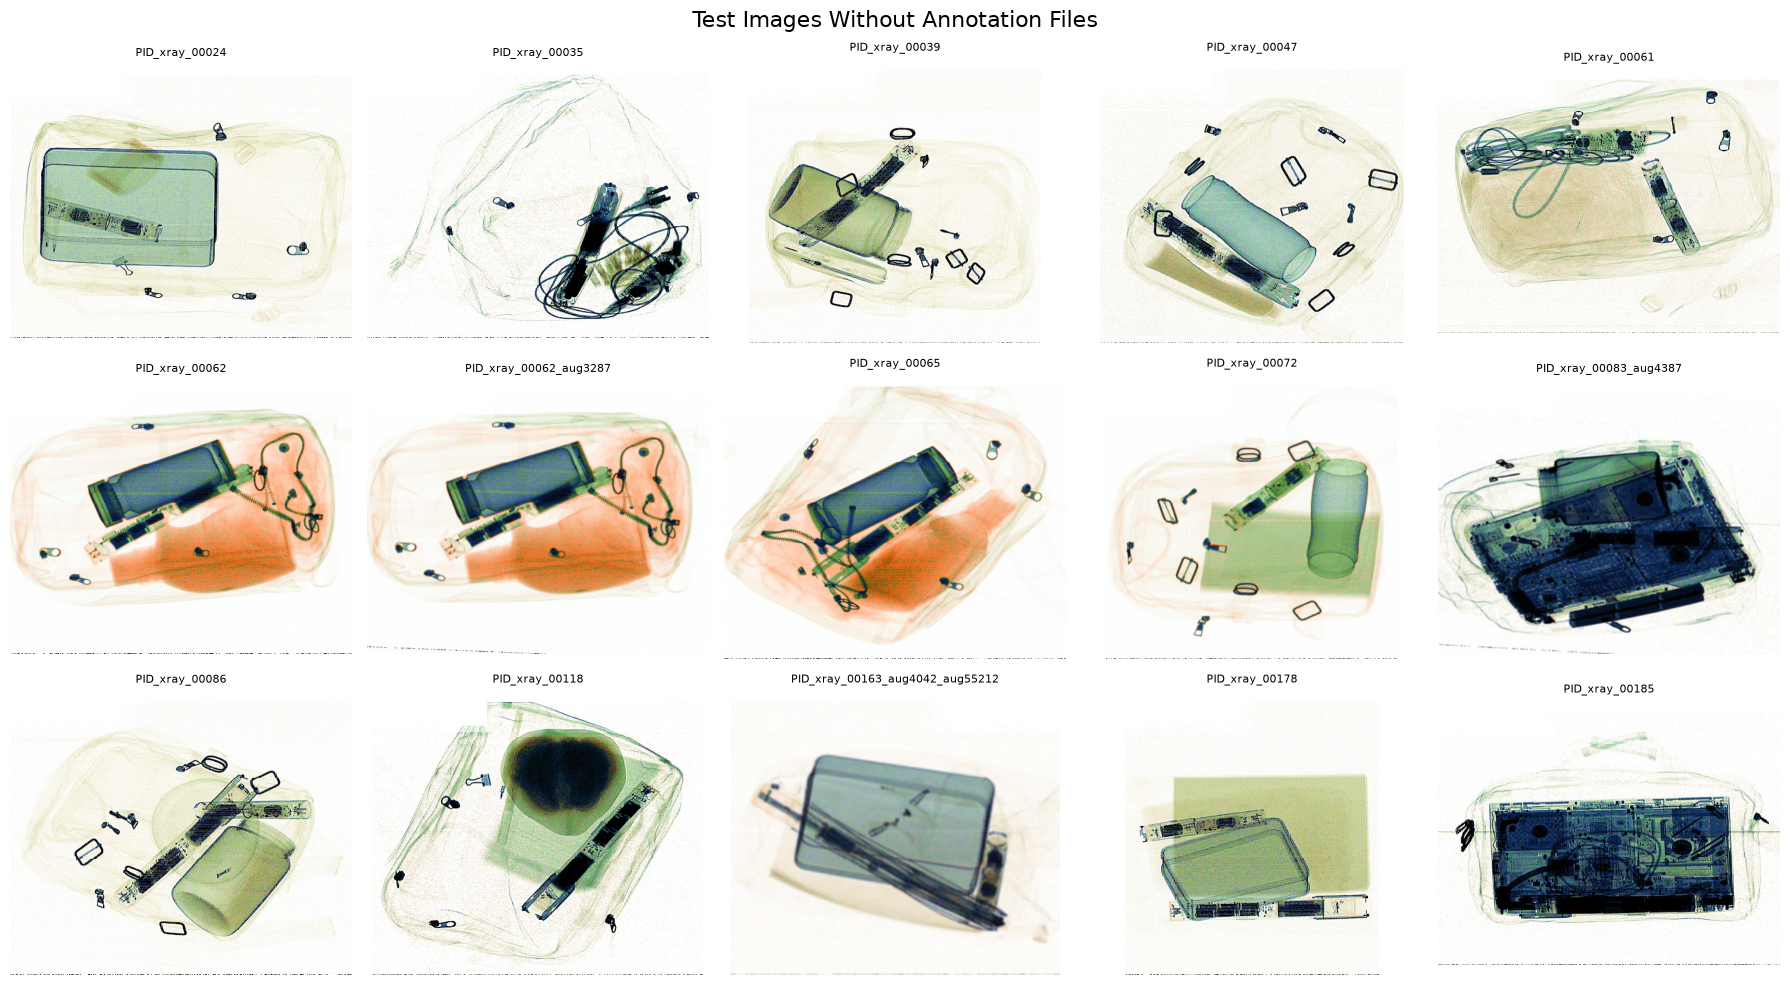

In [ ]:
fig, axes = plt.subplots(3, 5, figsize=(18, 10))

for ax, image_name in zip(axes.ravel(), unlabeled_test_images):

    image_path = TEST_IMAGES / f"{image_name}.jpg"

    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    ax.imshow(image)
    ax.set_title(image_name, fontsize=8)
    ax.axis("off")

plt.suptitle("Test Images Without Annotation Files", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
box_data = []

for label_file in LABEL_DIR.glob("*/*.txt"):

    with open(label_file, "r") as file:

        for line in file:

            values = line.strip().split()

            if len(values) != 5:
                continue

            class_id = int(values[0])
            x_center = float(values[1])
            y_center = float(values[2])
            box_width = float(values[3])
            box_height = float(values[4])

            box_area = box_width * box_height

            box_data.append({
                "class_id": class_id,
                "class_name": class_names[class_id],
                "x_center": x_center,
                "y_center": y_center,
                "width": box_width,
                "height": box_height,
                "area": box_area
            })

bbox_df = pd.DataFrame(box_data)

bbox_df.head()

,class_id,class_name,x_center,y_center,width,height,area
0,1,Pliers,0.591066,0.480730,0.404107,0.236525,0.095581
1,8,Sprayer,0.673541,0.611752,0.124688,0.387424,0.048307
2,11,Lighter,0.657332,0.843594,0.187032,0.106319,0.019885
3,9,HandCuffs,0.490412,0.645144,0.254836,0.325566,0.082966
4,11,Lighter,0.322619,0.658631,0.093810,0.124405,0.011670


In [ ]:
bbox_df[["width", "height", "area"]].describe()

,width,height,area
count,18014.000000,18014.000000,18014.000000
mean,0.329320,0.255559,0.090525
std,0.186784,0.135590,0.079804
min,0.012931,0.013417,0.000568
25%,0.183486,0.150258,0.032893
50%,0.299905,0.239733,0.070695
75%,0.447991,0.338602,0.120277
max,0.957789,0.877173,0.644360


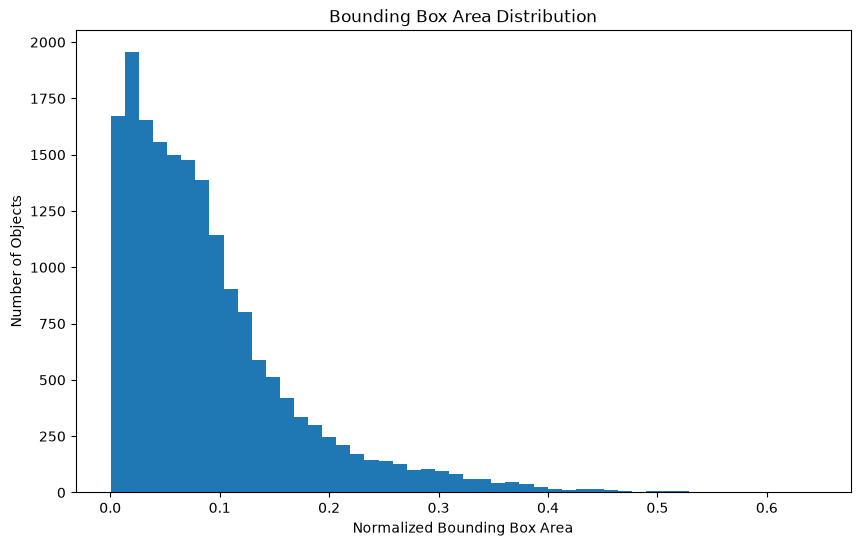

In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(
    bbox_df["area"],
    bins=50
)

plt.title("Bounding Box Area Distribution")
plt.xlabel("Normalized Bounding Box Area")
plt.ylabel("Number of Objects")

plt.show()

In [ ]:
def classify_size(area):

    if area < 0.02:
        return "Small"

    elif area < 0.10:
        return "Medium"

    else:
        return "Large"


bbox_df["size_category"] = bbox_df["area"].apply(classify_size)

print(
    bbox_df["size_category"].value_counts()
)

size_category
Medium    9280
Large     5988
Small     2746
Name: count, dtype: int64


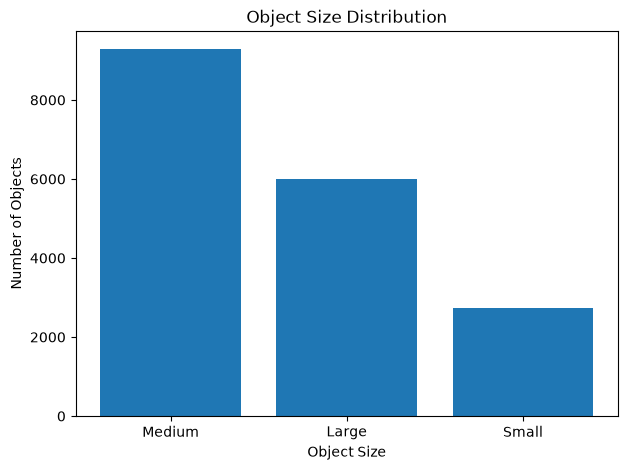

In [ ]:
size_counts = bbox_df["size_category"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    size_counts.index,
    size_counts.values
)

plt.title("Object Size Distribution")
plt.xlabel("Object Size")
plt.ylabel("Number of Objects")

plt.show()